In [1]:
import torch
import matplotlib.pyplot as plt

path = "/Users/debanjan_5402/Desktop/Conditional-GAN-based-Image-Restoration-from-Speckle-Interference-Pattern" \
"/_checkpoints/latest_checkpoint_unet_pretraining.pt"

checkpoint = torch.load(path)

history = checkpoint['history']

train_loss = history["train"]['loss']
train_ssim = history["train"]['ssim']
train_psnr = history["train"]['psnr']

val_loss = history["val"]['loss']
val_ssim = history["val"]['ssim']
val_psnr = history["val"]['psnr']

epochs = range(1, len(train_loss)+1)

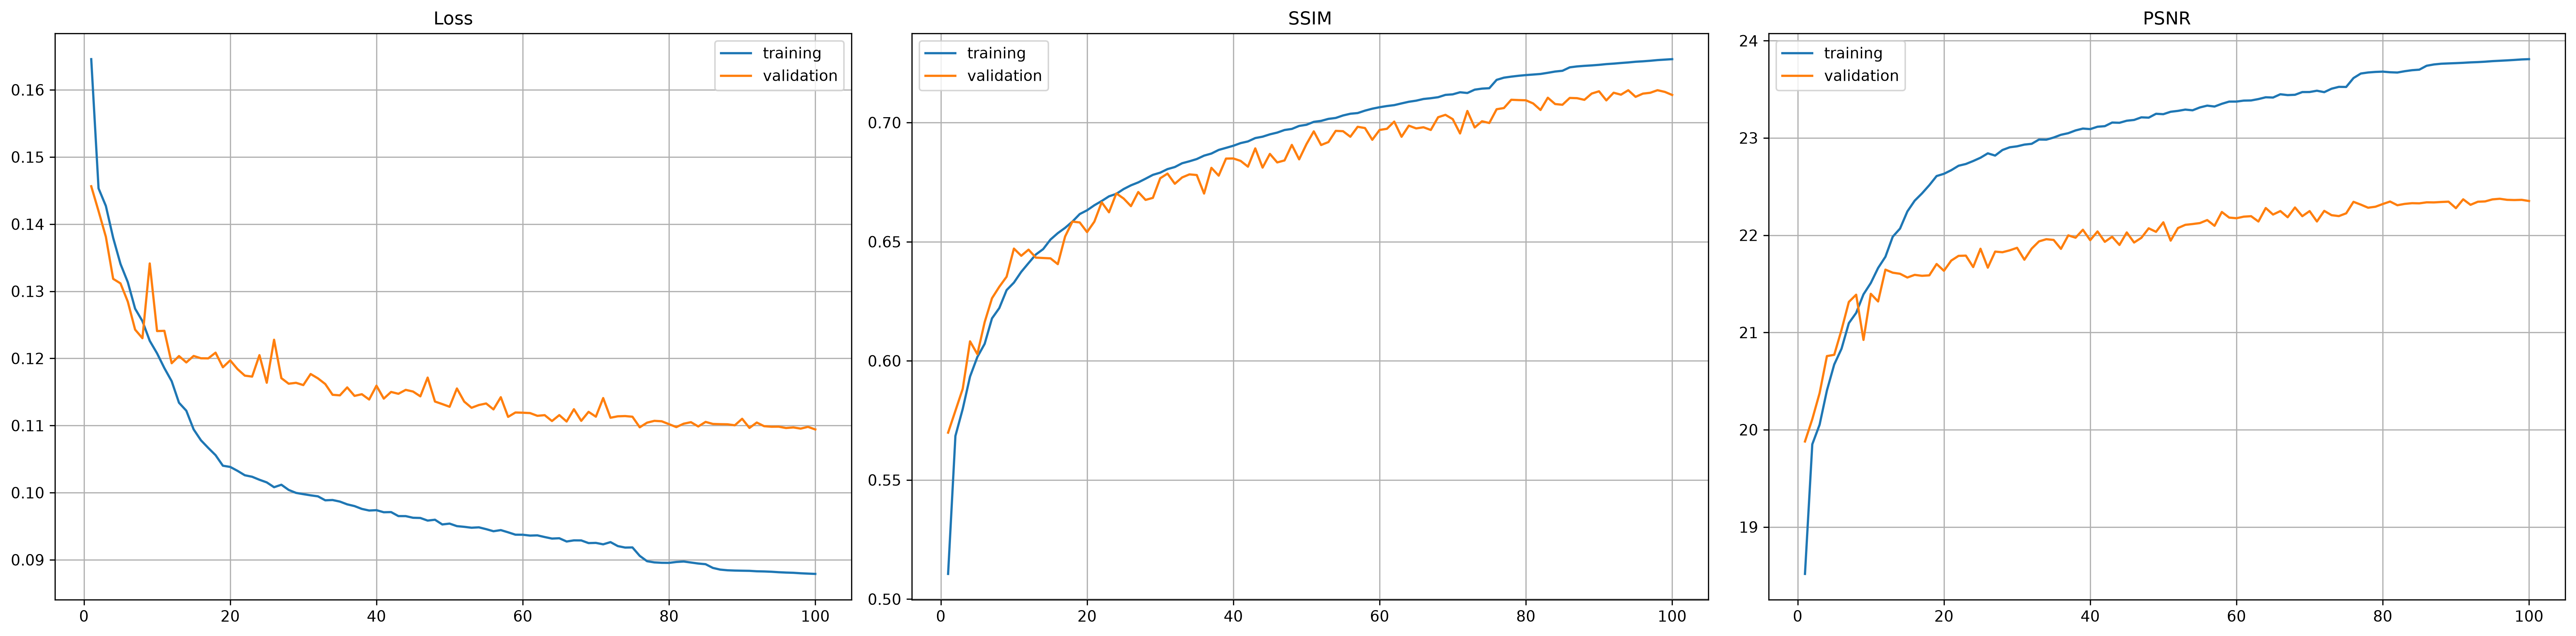

In [2]:
plt.figure(figsize=(24, 6), dpi=300)

plt.subplot(131)
plt.plot(epochs, train_loss, '-', label='training')
plt.plot(epochs, val_loss, '-', label='validation')
plt.legend()
plt.grid()
plt.title("Loss")

plt.subplot(132)
plt.plot(epochs, train_ssim, '-', label='training')
plt.plot(epochs, val_ssim, '-', label='validation')
plt.legend()
plt.grid()
plt.title("SSIM")

plt.subplot(133)
plt.plot(epochs, train_psnr, '-', label='training')
plt.plot(epochs, val_psnr, '-', label='validation')
plt.legend()
plt.grid()
plt.title("PSNR")

plt.tight_layout()
plt.show()


In [3]:
checkpoint['history']['best']

{'epoch': 98,
 'train_loss': 0.08799324820190668,
 'train_ssim': 0.7262195944786072,
 'train_psnr': 23.802082061767578,
 'val_loss': 0.10953964388116877,
 'val_ssim': 0.7135730385780334,
 'val_psnr': 22.36139678955078}

In [4]:
import torch
import matplotlib.pyplot as plt
from pathlib import Path

dir = Path("/Users/debanjan_5402/Desktop/Conditional-GAN-based-Image-Restoration-from-Speckle-Interference-Pattern/dataset/test")
mse_paths = sorted([str(file.resolve()) for file in dir.glob('**/*_unet_lr0.001_batch4_mse_data.pt') if file.is_file()])
l1_paths = sorted([str(file.resolve()) for file in dir.glob('**/*_unet_lr0.001_batch4_l1_data.pt') if file.is_file()])

l1_recons, l1_ssims, l1_psnrs = [], [], []
mse_recons, mse_ssims, mse_psnrs = [], [], []
orgs = []

for l1_path, mse_path in zip(l1_paths, mse_paths):
    l1_data = torch.load(l1_path)
    mse_data = torch.load(mse_path)

    l1_recons.append(l1_data['predicted'].squeeze(0))
    l1_ssims.append(l1_data['ssim'])
    l1_psnrs.append(l1_data['psnr'])

    orgs.append(mse_data['target'])
    mse_recons.append(mse_data['predicted'])
    mse_ssims.append(mse_data['ssim'])
    mse_psnrs.append(mse_data['psnr'])

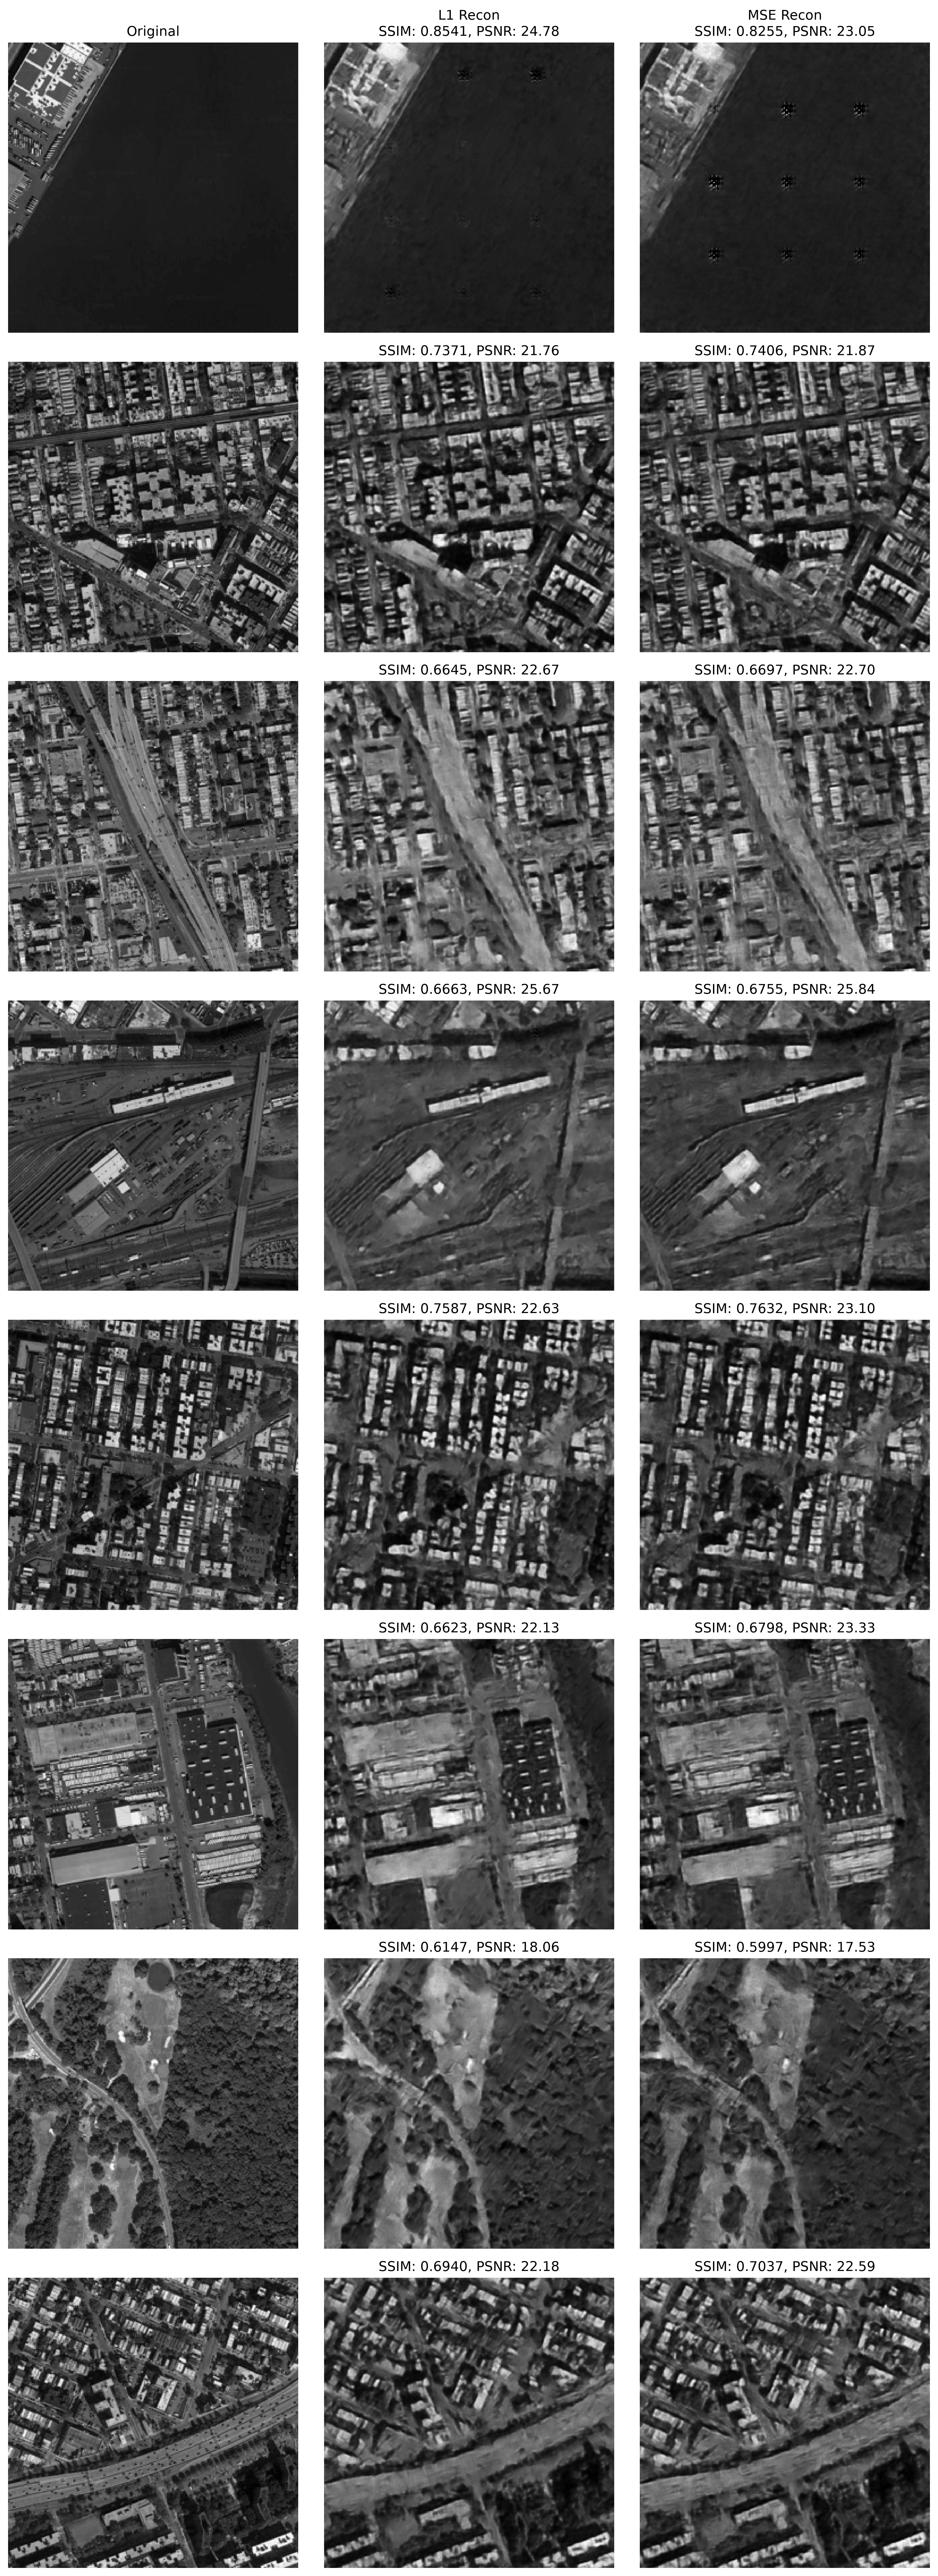

In [5]:
import matplotlib.pyplot as plt

n = 8

plt.figure(figsize=(3*4, n*4), dpi=300)

for i in range(n):
    # 1st column: Original / Ground Truth
    plt.subplot(n, 3, 3 * i + 1)
    plt.imshow(orgs[i].permute(1, 2, 0).cpu(), cmap="gray")
    plt.title("Original") if i == 0 else None
    plt.axis("off")

    # 2nd column: L1 Reconstruction
    plt.subplot(n, 3, 3 * i + 2)
    plt.imshow(l1_recons[i].permute(1, 2, 0).cpu(), cmap="gray")
    if i == 0:
        plt.title(f"L1 Recon\nSSIM: {l1_ssims[i]:0.4f}, PSNR: {l1_psnrs[i]:0.2f}") 
    else:
        plt.title(f"SSIM: {l1_ssims[i]:0.4f}, PSNR: {l1_psnrs[i]:0.2f}") 

    plt.axis("off")

    # 3rd column: MSE Reconstruction
    plt.subplot(n, 3, 3 * i + 3)
    plt.imshow(mse_recons[i].permute(1, 2, 0).cpu(), cmap="gray")
    if i == 0:
        plt.title(f"MSE Recon\nSSIM: {mse_ssims[i]:0.4f}, PSNR: {mse_psnrs[i]:0.2f}") 
    else:
        plt.title(f"SSIM: {mse_ssims[i]:0.4f}, PSNR: {mse_psnrs[i]:0.2f}") 
    plt.axis("off")

# tight_layout OUTSIDE the loop
plt.tight_layout()
plt.show()

In [6]:
import math

def get_mean_std(X:list):
    mean = sum(X)/len(X)
    v = [(x-mean)**2 for x in X]
    var = sum(v)/len(v)
    std = math.sqrt(var)
    return mean, std



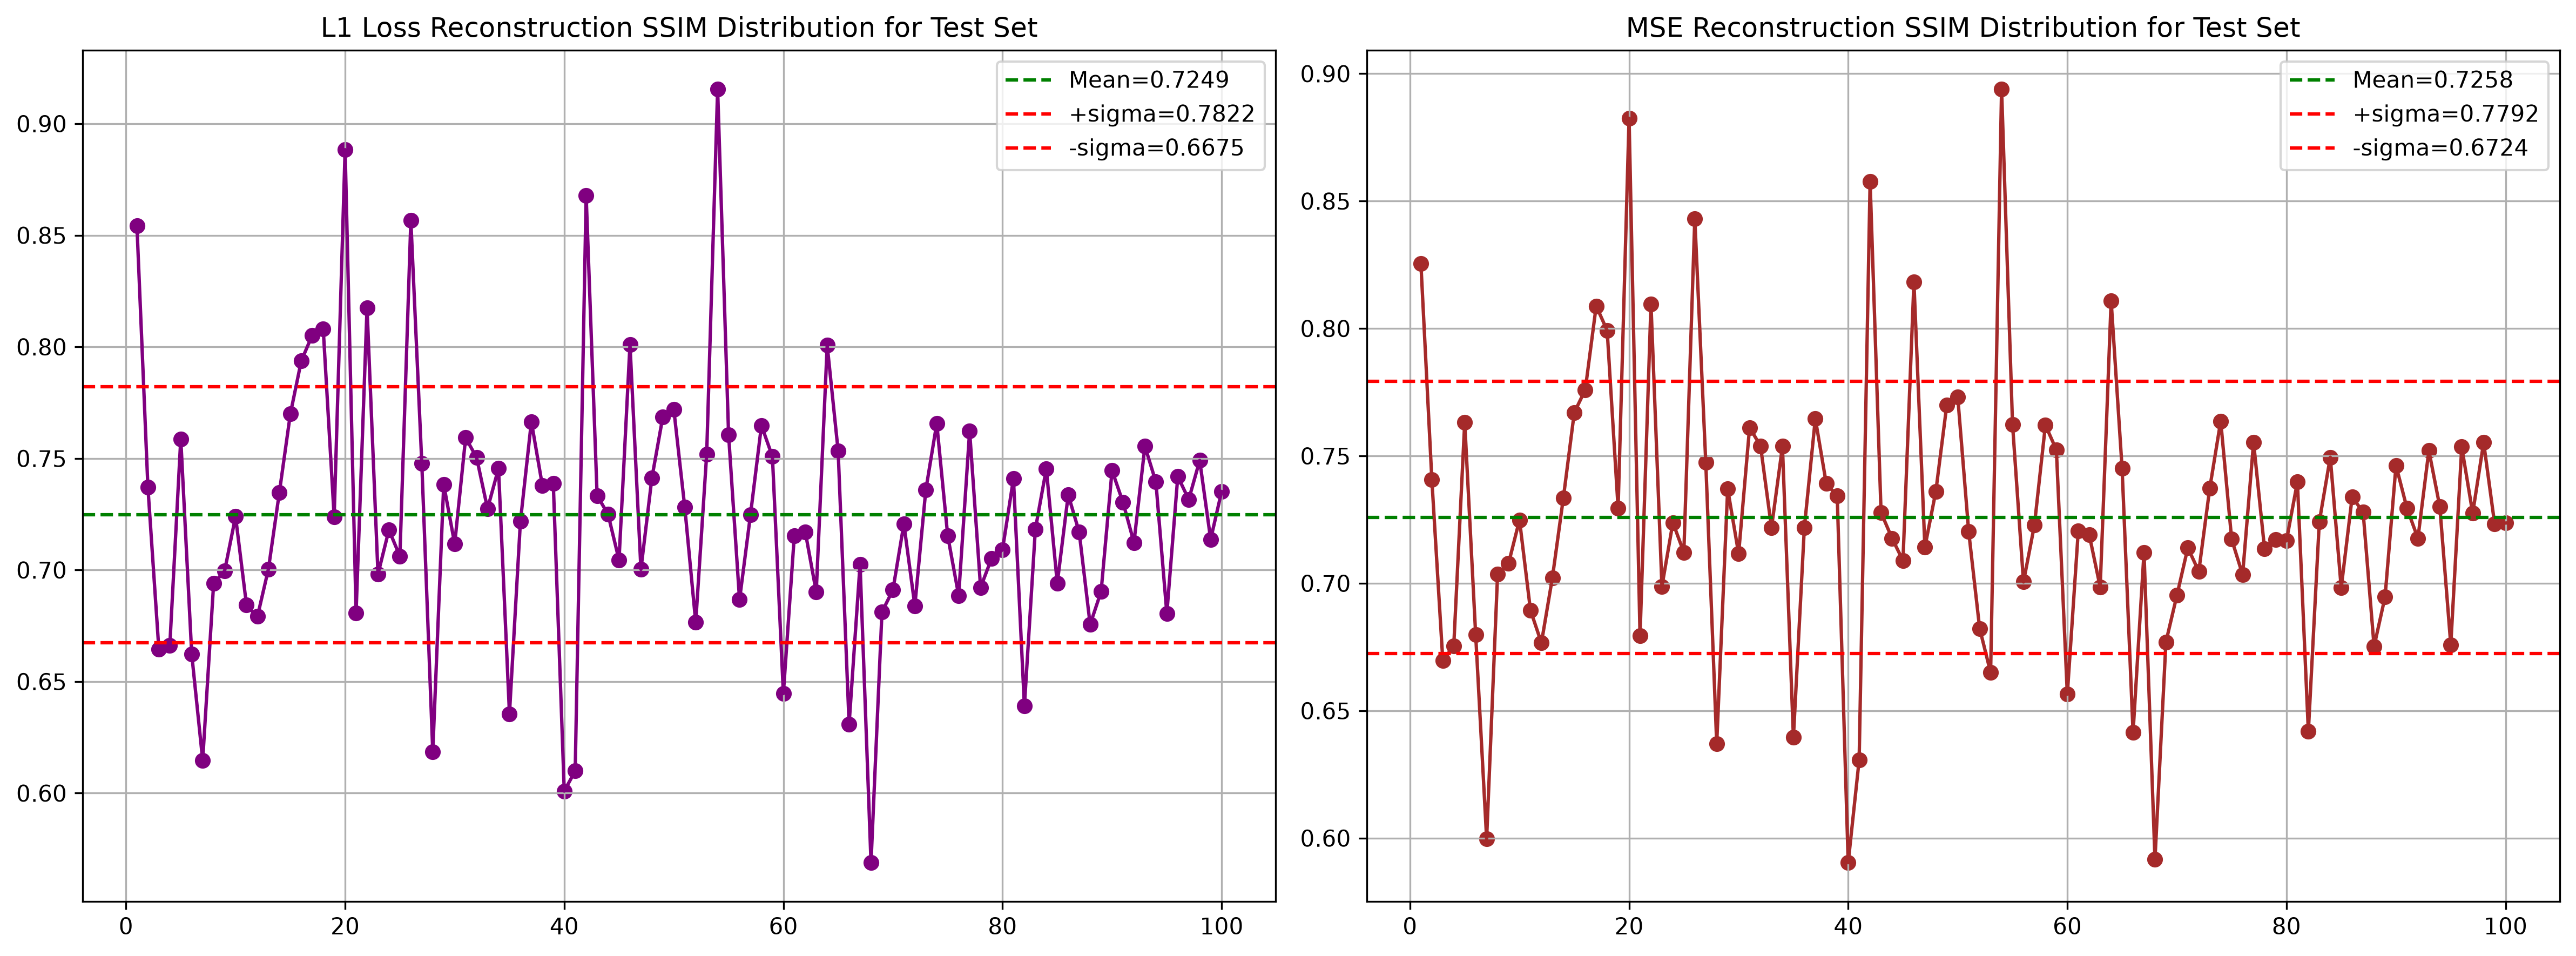

In [7]:
l1_mean, l1_std = get_mean_std(l1_ssims)
mse_mean, mse_std = get_mean_std(mse_ssims)

plt.figure(figsize=(4*2*2, 3*2), dpi=300)

plt.subplot(121)
plt.plot(range(1, len(l1_ssims)+1), l1_ssims, color='purple', linestyle = '-')
plt.scatter(range(1, len(l1_ssims)+1), l1_ssims, color='purple')
plt.axhline(l1_mean, linestyle='--', color='green', label=f"Mean={l1_mean:0.4f}")
plt.axhline(l1_mean + l1_std, linestyle='--', color='red', label=f"+sigma={(l1_mean + l1_std):0.4f}")
plt.axhline(l1_mean - l1_std, linestyle='--', color='red', label=f"-sigma={(l1_mean - l1_std):0.4f}")
plt.title("L1 Loss Reconstruction SSIM Distribution for Test Set")
plt.grid()
plt.legend()

plt.subplot(122)
plt.plot(range(1, len(mse_ssims)+1), mse_ssims, color='brown', linestyle='-')
plt.scatter(range(1, len(mse_ssims)+1), mse_ssims, color='brown')
plt.axhline(mse_mean, linestyle='--', color='green', label=f"Mean={mse_mean:0.4f}")
plt.axhline(mse_mean + mse_std, linestyle='--', color='red', label=f"+sigma={(mse_mean + mse_std):0.4f}")
plt.axhline(mse_mean - mse_std, linestyle='--', color='red', label=f"-sigma={(mse_mean - mse_std):0.4f}")
plt.title("MSE Reconstruction SSIM Distribution for Test Set")
plt.legend()

plt.tight_layout()
plt.grid()

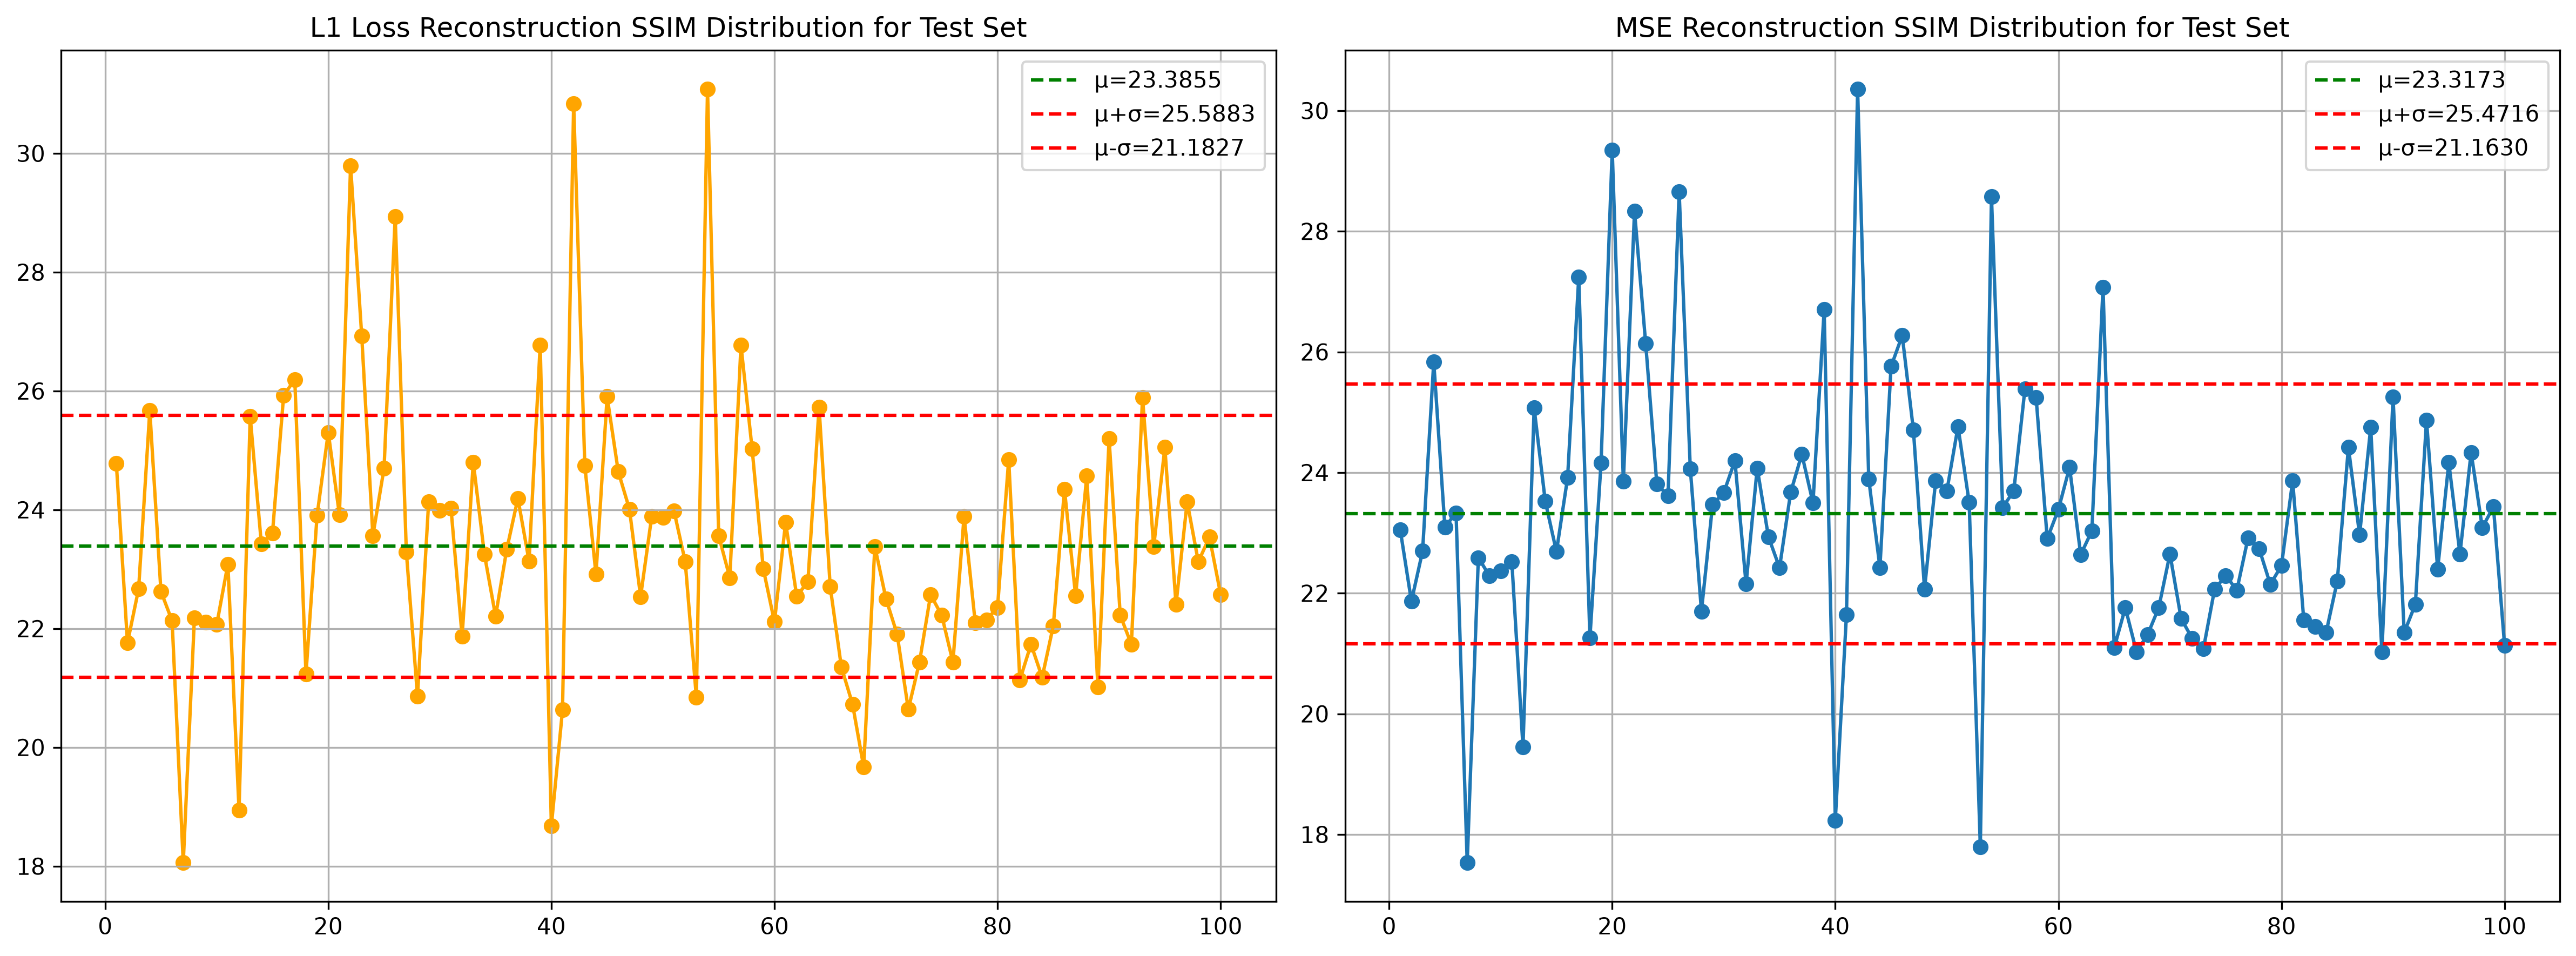

In [8]:
μ_l1, σ_l1 = get_mean_std(l1_psnrs)
μ_mse, σ_mse = get_mean_std(mse_psnrs)


plt.figure(figsize=(4*2*2, 3*2), dpi=300)

plt.subplot(121)
plt.plot(range(1, len(l1_psnrs)+1), l1_psnrs, color='orange', linestyle = '-')
plt.scatter(range(1, len(l1_psnrs)+1), l1_psnrs, color='orange')
plt.axhline(μ_l1, linestyle='--', color='green', label=f"μ={μ_l1:0.4f}")
plt.axhline(μ_l1 + σ_l1, linestyle='--', color='red', label=f"μ+σ={(μ_l1 + σ_l1):0.4f}")
plt.axhline(μ_l1 - σ_l1, linestyle='--', color='red', label=f"μ-σ={(μ_l1 - σ_l1):0.4f}")
plt.title("L1 Loss Reconstruction SSIM Distribution for Test Set")
plt.grid()
plt.legend()

plt.subplot(122)
plt.plot(range(1, len(mse_psnrs)+1), mse_psnrs, 'o-')
plt.axhline(μ_mse, linestyle='--', color='green', label=f"μ={μ_mse:0.4f}")
plt.axhline(μ_mse + σ_mse, linestyle='--', color='red', label=f"μ+σ={(μ_mse + σ_mse):0.4f}")
plt.axhline(μ_mse - σ_mse, linestyle='--', color='red', label=f"μ-σ={(μ_mse - σ_mse):0.4f}")
plt.title("MSE Reconstruction SSIM Distribution for Test Set")
plt.legend()

plt.tight_layout()
plt.grid()